Cubic Spline Interpolation:
Mean Squared Error: 0.0, R-Squared: 1.0

Polynomial Fit (degree 3):
Coefficients: [ 0.07407407 -0.55555556  1.1005291   0.06349206]
Mean Squared Error: 0.16931216931216939, R-Squared: 0.32275132275132246

Better MSE:  Cubic Spline
Better R-Squared:  Cubic Spline
The Cubic Spline method is the better fit.


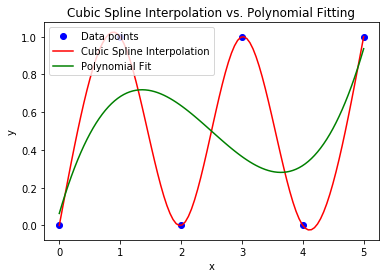

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


def compute_mse(Y, Y_fit):
    return np.mean((Y - Y_fit)**2)


def compute_rsq(Y, Y_fit):
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - Y_fit)**2)
    return 1.0 - (ss_res / ss_total)


def solve_and_plot_cspline(X, Y, X_interp):
    cs = CubicSpline(x, y, bc_type='natural')
    Y_fit = cs(X)
    Y_interp = cs(X_interp)
    mse = compute_mse(Y, Y_fit)
    rsq = compute_rsq(Y, Y_fit)
    plt.plot(X_interp, Y_interp, 'r-', label="Cubic Spline Interpolation")
    print("Cubic Spline Interpolation:")
    print(f"Mean Squared Error: {mse}, R-Squared: {rsq}\n")
    return mse, rsq


def solve_and_plot_polyfit(X, Y, X_interp, degree=3):
    c = np.polyfit(X, Y, degree)
    p = np.poly1d(c)
    Y_fit = p(X)
    Y_interp = p(X_interp)
    mse = compute_mse(Y, Y_fit)
    rsq = compute_rsq(Y, Y_fit)
    plt.plot(X_interp, Y_interp, 'g-', label="Polynomial Fit")
    print(f"Polynomial Fit (degree {degree}):")
    print(f"Coefficients: {c}")
    print(f"Mean Squared Error: {mse}, R-Squared: {rsq}\n")
    return mse, rsq


def evaluate_fits(cspline_stats, polyfit_stats):
    cspline_mse = cspline_stats[0] < polyfit_stats[0]
    cspline_rsq = cspline_stats[1] > polyfit_stats[1]
    print("Better MSE: ", "Cubic Spline" if cspline_mse else "Polynomial Fit")
    print("Better R-Squared: ", "Cubic Spline" if cspline_rsq else "Polynomial Fit")
    if cspline_mse and cspline_rsq:
        print("The Cubic Spline method is the better fit.")
    elif not (cspline_mse or cspline_rsq):
        print("The Polynomial Fit method is the better fit.")
    else:
        print("The best fit is unclear.")


X = np.array([0, 1, 2, 3, 4, 5])
Y = np.array([0, 1, 0, 1, 0, 1])
X_interp = np.linspace(0, 5, 100)

# Cubic Spline vs Polynomial Fitting
# print(f"Challenge A: Cubic Spline vs Polynomial Fitting")
# plt.figure(figsize=(4,9))
# plt.subplot(3, 1, 1)
plt.plot(x, y, 'bo', label="Data points")
cspline_stats = solve_and_plot_cspline(X, Y, X_interp)
polyfit_stats = solve_and_plot_polyfit(X, Y, X_interp)
plt.title("Cubic Spline Interpolation vs. Polynomial Fitting")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
evaluate_fits(cspline_stats, polyfit_stats)

plt.show()
